### A notebook to create croparray objects from videos and tracking files. Can run on lists of files in batch.

In [1]:
import croparray as ca
from pathlib import Path

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Input files
DATA_DIR = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\HT")
#DATA_DIR = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260331_HA_ZAK_HT\wDox\HT")
#DATA_DIR = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260331_HA_ZAK_HT\NoDox\HT")

CSV_FILES = sorted(DATA_DIR.glob("*_allspots.csv"))
VID_FILES = sorted(DATA_DIR.glob("PB_MAX*.tif"))
assert len(VID_FILES) == len(CSV_FILES), f"Mismatch: {len(VID_FILES)} videos vs {len(CSV_FILES)} csvs"

# Cropping parameters
XY_PAD = 10                         # Typically 5, but bigger if spots are > diffraction limited
Z_PAD = 1                           # Only used if tracking was also done in Z

# Physical metadata (should match TrackMate if TrackMate units not pixels)
DX = 0.130  ## pixel size
DY = 0.130 
DZ = .5      ## this is ignored if tracking was only done in 2D
DT = 1
UNITS = ["microns", "min"]
NOTES = 'A crop array in WT U2OS cells. Imaged once every minute in 2 channels on Terminator with HT after 5th frame (6-45). Ch1 = 12xSunTag-KDM5B-BoxB-MS2 labeled with mST-tagged anti-SunTag scFv. ch0 = MCP-Halo labeled with JF646. Used Sun+MCP APP. Spots were tracked in 2D on max-projected images using TrackMate.'
DATE_STR = "2026-03-31"

# Spot table handling
TRACKER = "auto"  # "trackmate" or "trackpy"; "auto" automatically determines; None for croparray
KEEP_COLS = ["MEAN_INTENSITY_CH1","TOTAL_INTENSITY_CH1", "CONTRAST_CH1", "SNR_CH1"]  # Optional; Note: sister colums are kept too (_CH2, _CH3...)

# ====================================
# PARAMETERS THAT DON'T NEED TO CHANGE
# ====================================
# Output
OUT_SUBDIR = "CropArrays"          # created inside DATA_DIR
OUT_EXT = ".nc"                    # standard is .nc, but can change

# Axis handling
AXES_SOURCE_INDEX = 0              # which video to use for axis definition; safe 0 (always there)


In [3]:
CSV_FILES, VID_FILES

([WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_Cell03_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_Cell05_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_Cell07_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_stretchy_slow_response_Cell02_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_stretchy_slow_response_Cell04_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_stretchy_slow_response_Cell06_allspots.csv'),
  WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/PB_MAX_weird_channels_Cell01_allspots.csv')],
 [WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_delta

In [4]:
# Build and save croparrays. This will not overwrite existing croparrays (may need to restart kernel if you delete .nc files and try to rerun)
written = ca.build.make_croparrays(VID_FILES, CSV_FILES, out_dir=DATA_DIR/OUT_SUBDIR, out_ext=OUT_EXT, tracker=TRACKER, xy_um_per_px=DX, z_um_per_plane=DZ, define_axes=True, keep_cols=KEEP_COLS, axes_source_index=AXES_SOURCE_INDEX, xy_pad=XY_PAD, z_pad=Z_PAD, dx=DX, dy=DY, dz=DZ, dt=DT, units=UNITS, date=DATE_STR, notes=NOTES, as_object=False, skip_existing=True, progress=True)

c:\Users\tstasevi\AppData\Local\anaconda3\envs\croparray_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
croparray:   0%|          | 0/7 [00:00<?, ?file/s]

Original video dimensions: (1, 46, 1, 1024, 1024, 2)
Padded video dimensions: (1, 46, 1, 1046, 1046, 2)
Max # of spots per frame: 131


croparray:  14%|█▍        | 1/7 [00:19<01:54, 19.10s/file]

Original video dimensions: (1, 46, 1, 1024, 1024, 2)
Padded video dimensions: (1, 46, 1, 1046, 1046, 2)
Max # of spots per frame: 69


croparray:  29%|██▊       | 2/7 [00:31<01:16, 15.29s/file]

...

croparray:  71%|███████▏  | 5/7 [01:07<00:25, 12.66s/file]

Original video dimensions: (1, 46, 1, 1024, 1024, 2)
Padded video dimensions: (1, 46, 1, 1046, 1046, 2)
Max # of spots per frame: 74


croparray:  86%|████████▌ | 6/7 [01:18<00:12, 12.09s/file]

Original video dimensions: (1, 46, 1, 1024, 1024, 2)
Padded video dimensions: (1, 46, 1, 1046, 1046, 2)
Max # of spots per frame: 261


croparray: 100%|██████████| 7/7 [01:31<00:00, 13.03s/file]


Check croparrays

In [5]:
NC_DIR = DATA_DIR/OUT_SUBDIR
NC_FILES = sorted(NC_DIR.glob("*.nc"))
NC_FILES

[WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_Cell03.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_Cell05.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_Cell07.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_stretchy_slow_response_Cell02.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_stretchy_slow_response_Cell04.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_stretchy_slow_response_Cell06.nc'),
 WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/HT/CropArrays/PB_MAX_weird_channels_Cell01.nc')]

In [6]:
# Check croparray 
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(NC_FILES[0], as_object=True)

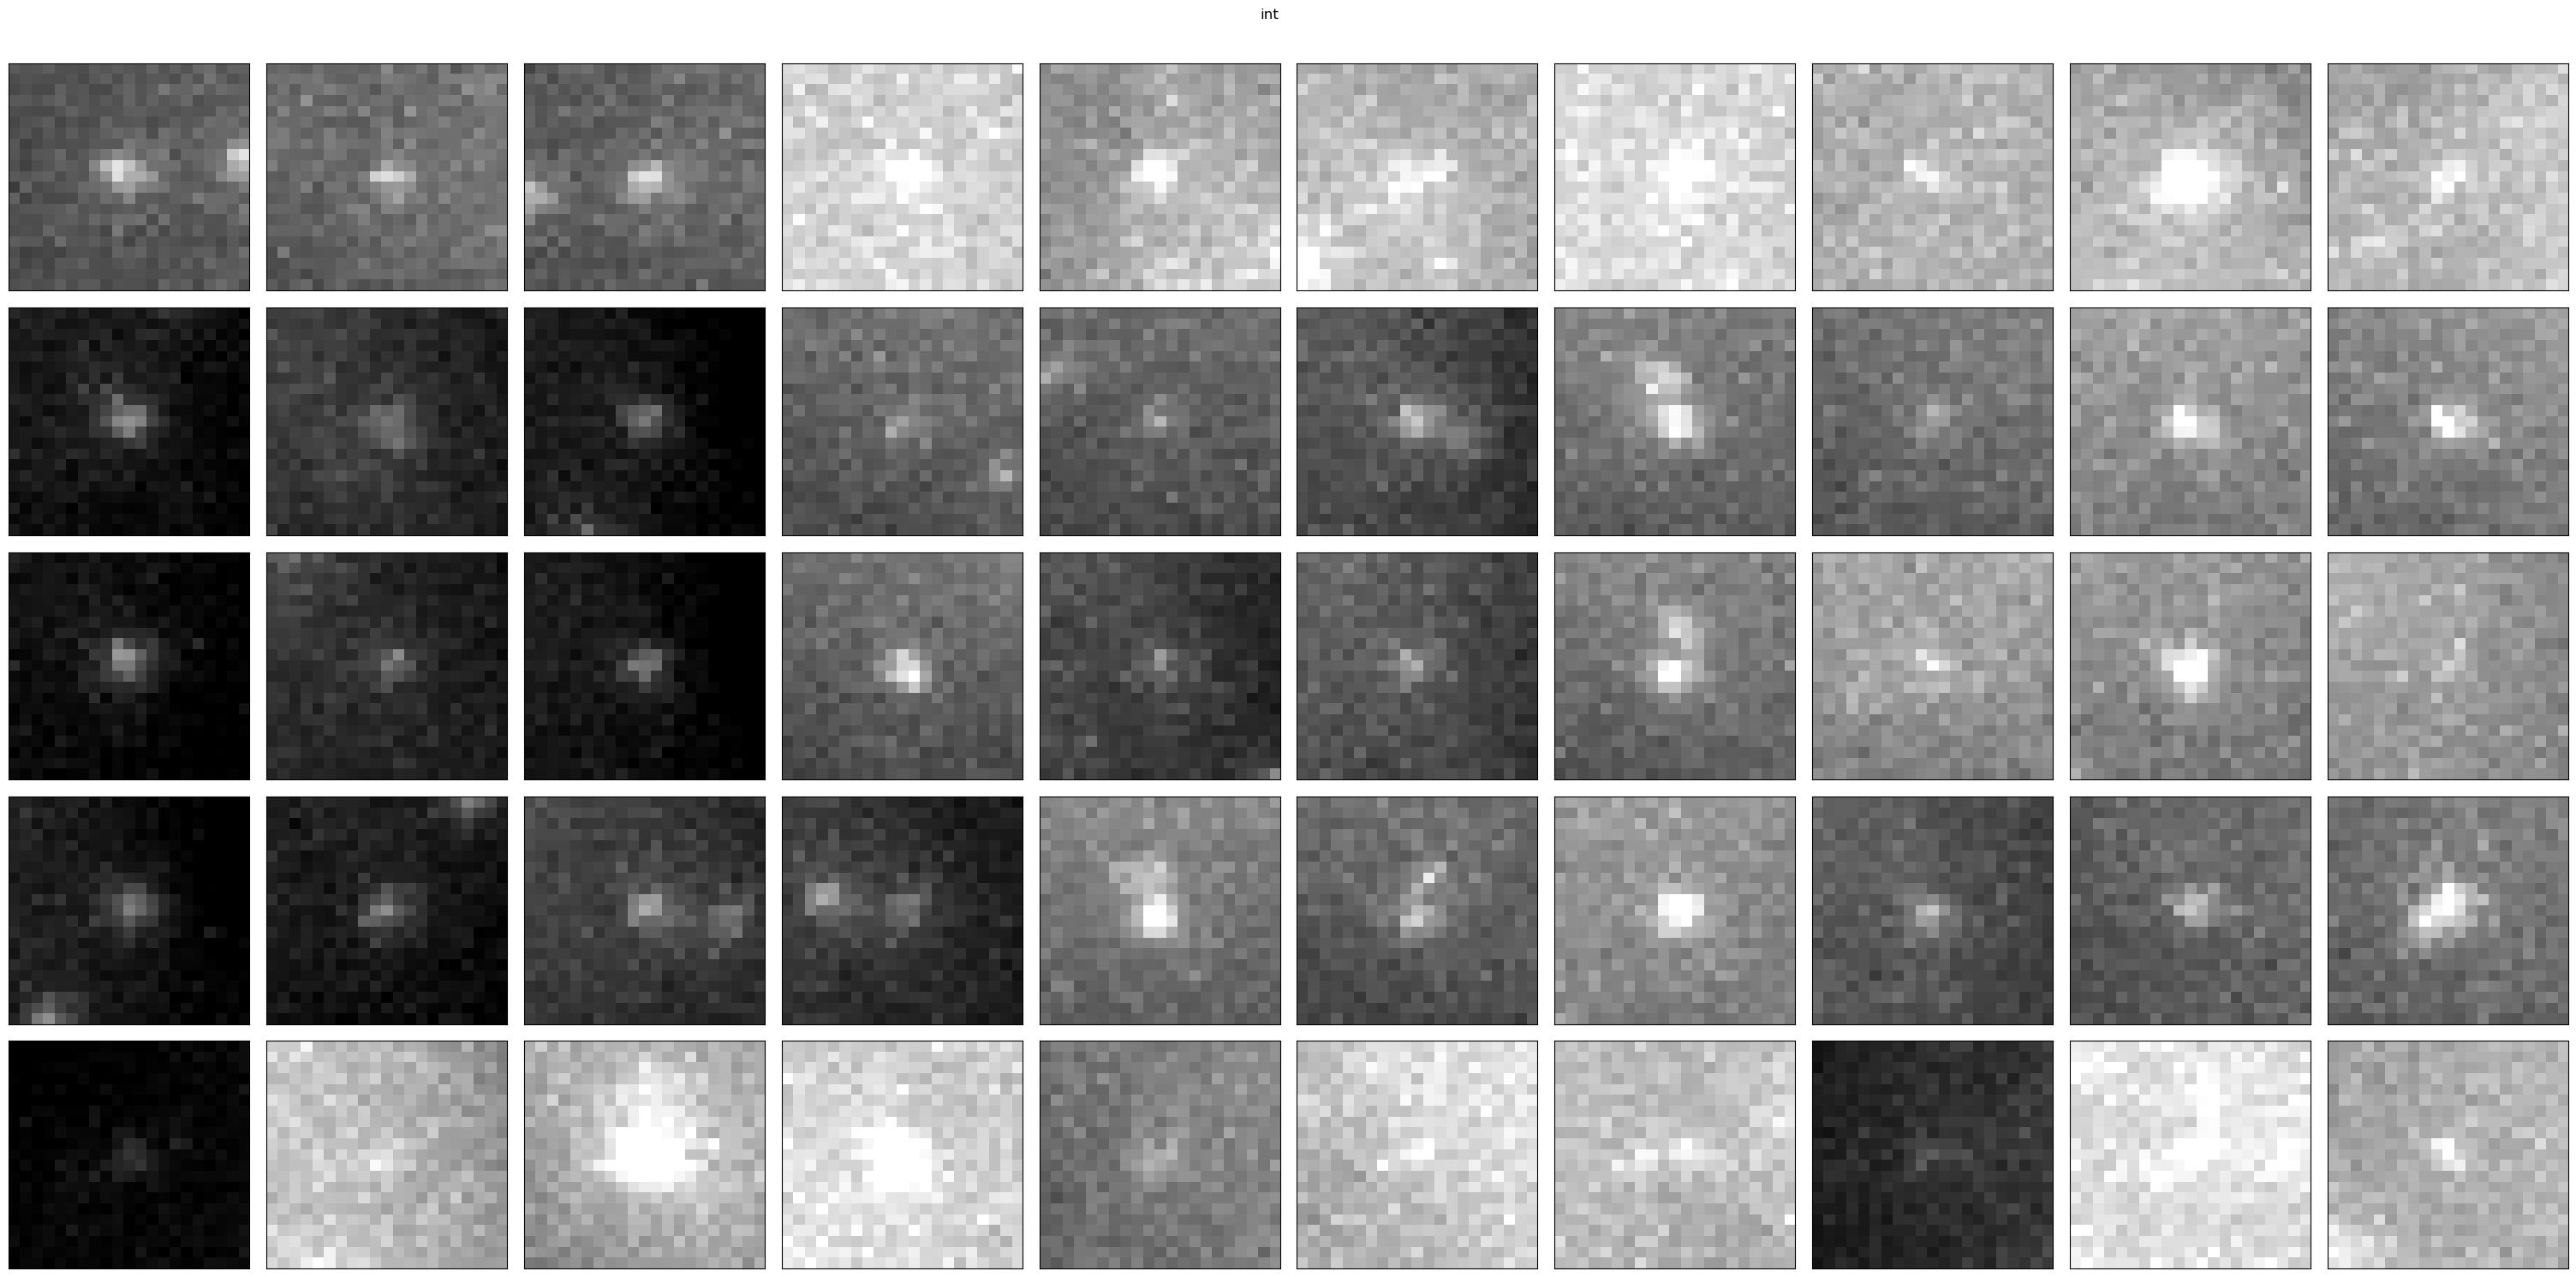

In [7]:
my_ca.isel(fov=0,z=0,ch=1).plot.plot_croparray_crops(n=(0,10,1), layer='int',t=(0,5,1), col='n');

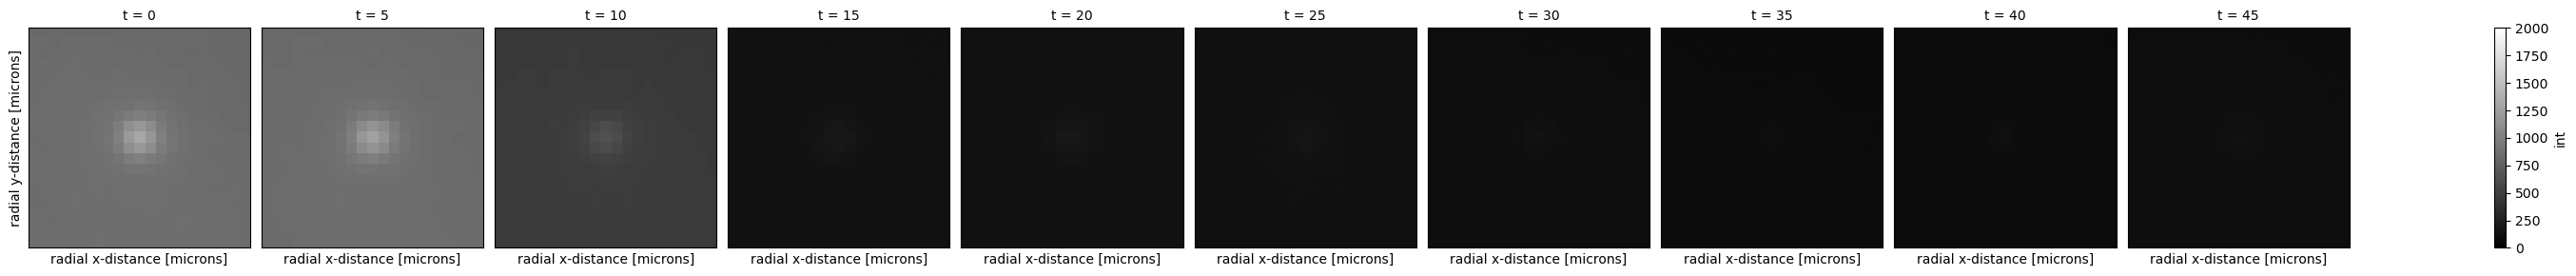

In [8]:
my_ca['int'].isel(fov=0,z=0,ch=1).mean(dim=['n']).rolling(t=5, center=True, min_periods=1).mean().isel(t=slice(None, None, 5)).plot.imshow(col="t", cmap='gray',robust=True, vmin=0,vmax=2000,xticks=[],yticks=[],)